# Ford Circles Demo - GPU Parallel Generation

This notebook demonstrates the generation of Ford circles (kissing circles) using CUDA for parallel computation on GPU.

Ford circles are tangent circles associated with rational numbers on the real line. Each circle is centered at (p/q, 1/q²) with radius 1/q² for a fraction p/q in lowest terms.

In [1]:
import numpy as np
from numba import cuda
import math
import matplotlib.pyplot as plt

## CUDA Kernel for Circle Generation

This kernel computes the next generation of circles using the Descartes circle theorem for circles tangent to a line.

In [2]:
# Numba CUDA kernel requires math.sqrt instead of np.sqrt
@cuda.jit
def generate_next_generation(ks, kzs_r, out_ks, out_kzs_r, n_parents):
    idx = cuda.grid(1)
    if idx < n_parents:
        # Parents
        k1 = ks[idx * 2]
        k2 = ks[idx * 2 + 1]
        kz1_r = kzs_r[idx * 2]
        kz2_r = kzs_r[idx * 2 + 1]

        # 1. New Curvature: k_new = k1 + k2 + 2*sqrt(k1*k2)
        # This is the Descartes result for two circles tangent to a line (k=0)
        sqrt_k1k2 = math.sqrt(k1 * k2)
        new_k = k1 + k2 + 2.0 * sqrt_k1k2

        # 2. New x-coordinate center (derived from the property x = (x1√k1 + x2√k2) / (√k1 + √k2))
        # Since kz = k * x, we calculate the new complex curvature's real part:
        x1 = kz1_r / k1
        x2 = kz2_r / k2
        new_x = (x1 * math.sqrt(k1) + x2 * math.sqrt(k2)) / (
            math.sqrt(k1) + math.sqrt(k2)
        )
        new_kz_r = new_k * new_x

        out_ks[idx] = new_k
        out_kzs_r[idx] = new_kz_r

## Ford Gasket Generation Function

Builds the Ford circles through successive generations using GPU parallelization.

In [3]:
def build_ford_gasket(generations=6):
    # Start with two circles of radius 0.5 (k=2) at x=0 and x=1

    all_circles = [(2.0, 0.0), (2.0, 2.0)]

    # Track current adjacent pairs
    current_ks = np.array([2.0, 2.0], dtype=np.float32)
    current_kzs_r = np.array([0.0, 2.0], dtype=np.float32)

    for _ in range(generations):
        n_pairs = len(current_ks) // 2
        d_ks = cuda.to_device(current_ks)
        d_kzs_r = cuda.to_device(current_kzs_r)

        out_ks = cuda.device_array(n_pairs, dtype=np.float32)
        out_kzs_r = cuda.device_array(n_pairs, dtype=np.float32)

        threads = 32
        blocks = (n_pairs + threads - 1) // threads
        generate_next_generation[blocks, threads](
            d_ks, d_kzs_r, out_ks, out_kzs_r, n_pairs
        )

        new_ks = out_ks.copy_to_host()
        new_kzs_r = out_kzs_r.copy_to_host()

        next_ks = []
        next_kzs_r = []

        for i in range(n_pairs):
            k_left = current_ks[i * 2]
            k_right = current_ks[i * 2 + 1]
            kz_left = current_kzs_r[i * 2]
            kz_right = current_kzs_r[i * 2 + 1]

            kn = new_ks[i]
            kzn = new_kzs_r[i]

            all_circles.append((kn, kzn))

            # Form new pairs for the next generation: (Left, New) and (New, Right)
            next_ks.extend([k_left, kn, kn, k_right])
            next_kzs_r.extend([kz_left, kzn, kzn, kz_right])

        current_ks = np.array(next_ks, dtype=np.float32)
        current_kzs_r = np.array(next_kzs_r, dtype=np.float32)

    return all_circles

## Visualization Function

Plots the generated Ford circles using matplotlib.

In [4]:
def visualize(circles):
    fig, ax = plt.subplots(figsize=(12, 5))
    # Sort circles by x-coordinate for a cleaner plot if needed
    for k, kz_r in circles:
        r = 1.0 / k
        x = kz_r / k
        # Every Ford circle is tangent to y=0, so y center is the radius
        circle = plt.Circle(
            (x, r), r, fill=True, color="C0", ec="black", lw=0.5, alpha=0.6
        )
        ax.add_artist(circle)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 0.55)
    ax.set_aspect("equal")
    plt.axhline(0, color="black", lw=2)
    plt.title("Kissing Ford Circles: GPU Parallel Generation")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

## Generate and Visualize Ford Circles

Run the generation with 9 generations (creates 511 circles total).

D:\scoop\apps\miniconda3\current\envs\pyflow\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
D:\scoop\apps\miniconda3\current\envs\pyflow\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
D:\scoop\apps\miniconda3\current\envs\pyflow\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
D:\scoop\apps\miniconda3\current\envs\pyflow\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


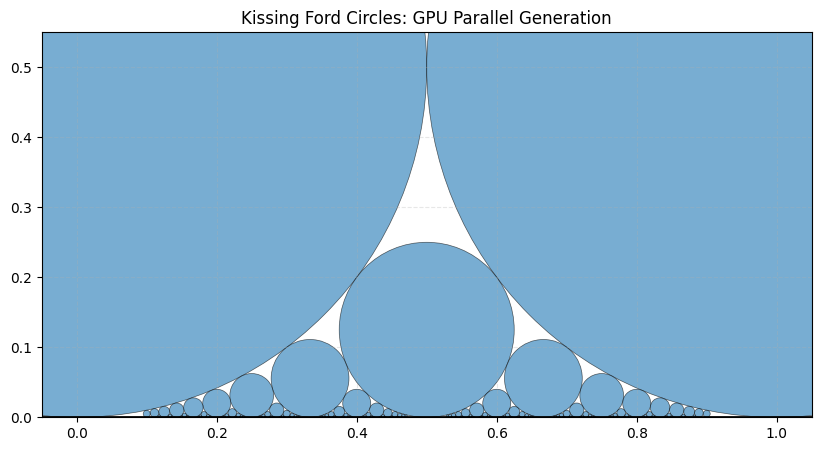

In [5]:
circles_data = build_ford_gasket(9)  # 9 generations generates 511 circles
visualize(circles_data)

## Notes

- Each circle is defined by its curvature (k = 1/radius)
- All circles are tangent to the x-axis (y=0)
- Adjacent circles are tangent to each other
- The GPU parallelization significantly speeds up generation for many generations
- Modify the `generations` parameter to see more or fewer circles